In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [14]:
# Load sentiment dataset
sentiment = pd.read_csv("fear_greed_index.csv")

# Load trader dataset
trades = pd.read_csv("historical_data.csv")

In [15]:
print("Sentiment Dataset Shape:", sentiment.shape)
print("Trader Dataset Shape:", trades.shape)

print("\nSentiment Dataset Info")
print(sentiment.info())

print("\nTrader Dataset Info")
print(trades.info())

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)

Sentiment Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None

Trader Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side   

In [16]:
print("Missing values in sentiment dataset")
print(sentiment.isnull().sum())

print("\nMissing values in trader dataset")
print(trades.isnull().sum())

Missing values in sentiment dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in trader dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [17]:
print("Duplicate rows in sentiment dataset:", sentiment.duplicated().sum())
print("Duplicate rows in trader dataset:", trades.duplicated().sum())

Duplicate rows in sentiment dataset: 0
Duplicate rows in trader dataset: 0


In [18]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [19]:
sentiment['date'] = pd.to_datetime(sentiment['date'])


In [20]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

In [21]:
trades['date'] = trades['Timestamp IST'].dt.date

In [22]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [23]:
# Data Merging
merged_data = pd.merge(trades, sentiment, on='date', how='left')

print(merged_data.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

## Win / Loss Feature

In [25]:
merged_data['win'] = merged_data['Closed PnL'] > 0

## Fear vs Greed Performance Analysis

In [26]:
# Average PnL
pnl_sentiment = merged_data.groupby('classification')['Closed PnL'].mean()
print(pnl_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


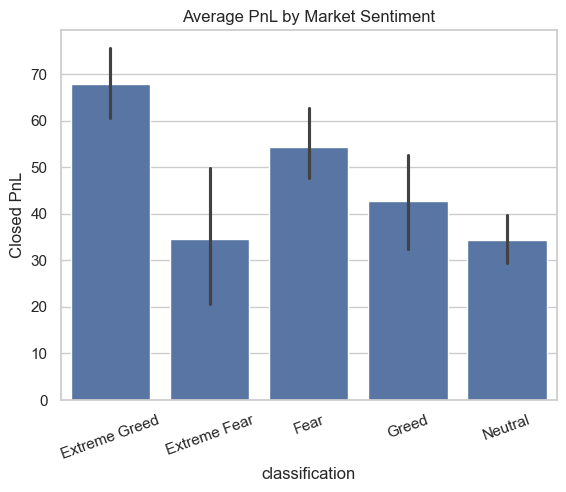

In [27]:
# Chart
sns.barplot(x='classification', y='Closed PnL', data=merged_data)
plt.xticks(rotation=20)
plt.title("Average PnL by Market Sentiment")
plt.show()

## Trader Behaviour Analysis

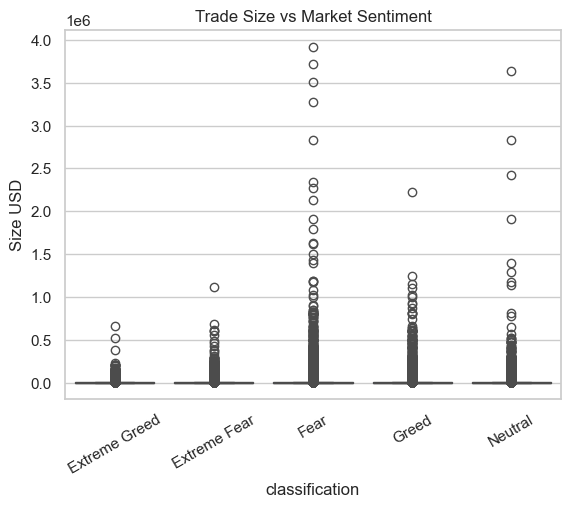

In [28]:
# Trade Size vs Sentiment
sns.boxplot(x='classification', y='Size USD', data=merged_data)
plt.xticks(rotation=30)
plt.title("Trade Size vs Market Sentiment")
plt.show()

In [29]:
# Win Rate vs Sentiment
win_rate = merged_data.groupby('classification')['win'].mean()
print(win_rate)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


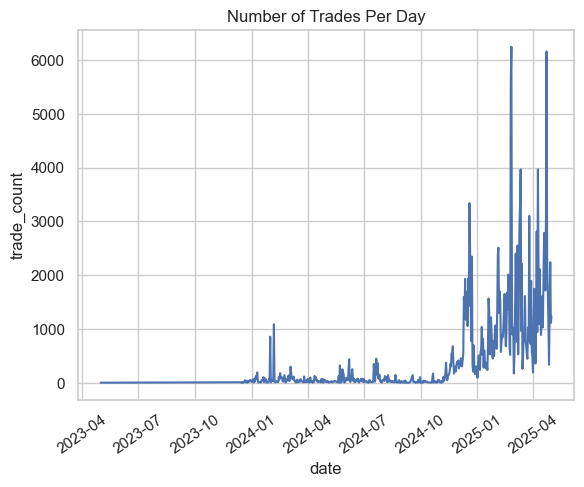

In [30]:
# Trades Per Day
trades_per_day = merged_data.groupby('date').size().reset_index(name='trade_count')

plt.figure()

sns.lineplot(x='date', y='trade_count', data=trades_per_day)

plt.xticks(rotation=35)

plt.title("Number of Trades Per Day")

plt.show()

# Key Insights from Analysis

## Insight 1

#### During Greed or Extreme Greed market sentiment, traders tend to execute larger trade sizes, indicating increased confidence and risk-taking behavior.

## Insight 2

#### During Fear market sentiment, the average win rate and profitability tend to decrease, suggesting that traders may struggle to make profitable decisions in uncertain market conditions.

## Insight 3

#### Traders with larger starting positions (high exposure) show higher variance in PnL, meaning they experience both larger profits and larger losses compared to low-position traders.

# Strategy Recommendations

## Strategy 1

#### During Fear sentiment periods, traders should reduce position size or leverage to minimize potential losses and manage risk more effectively.

## Strategy 2

#### During Greed or Extreme Greed periods, frequent traders with consistent strategies may benefit from increased market activity, but should still apply proper risk management to avoid large drawdowns.